<a href="https://colab.research.google.com/github/SrMishima/Probabilidad_Y_Estadistica/blob/main/Unidad6/Practica_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Probabilidad y estadistica

Unidad 6


2YY

25/05/26

Equipo formado por:

Torres Aragon Tadeo Salvador

Rios Silva Angel Alexander

Sebastian Villa Bernal

Profesor: José Gabriel Rodriguez Rivas

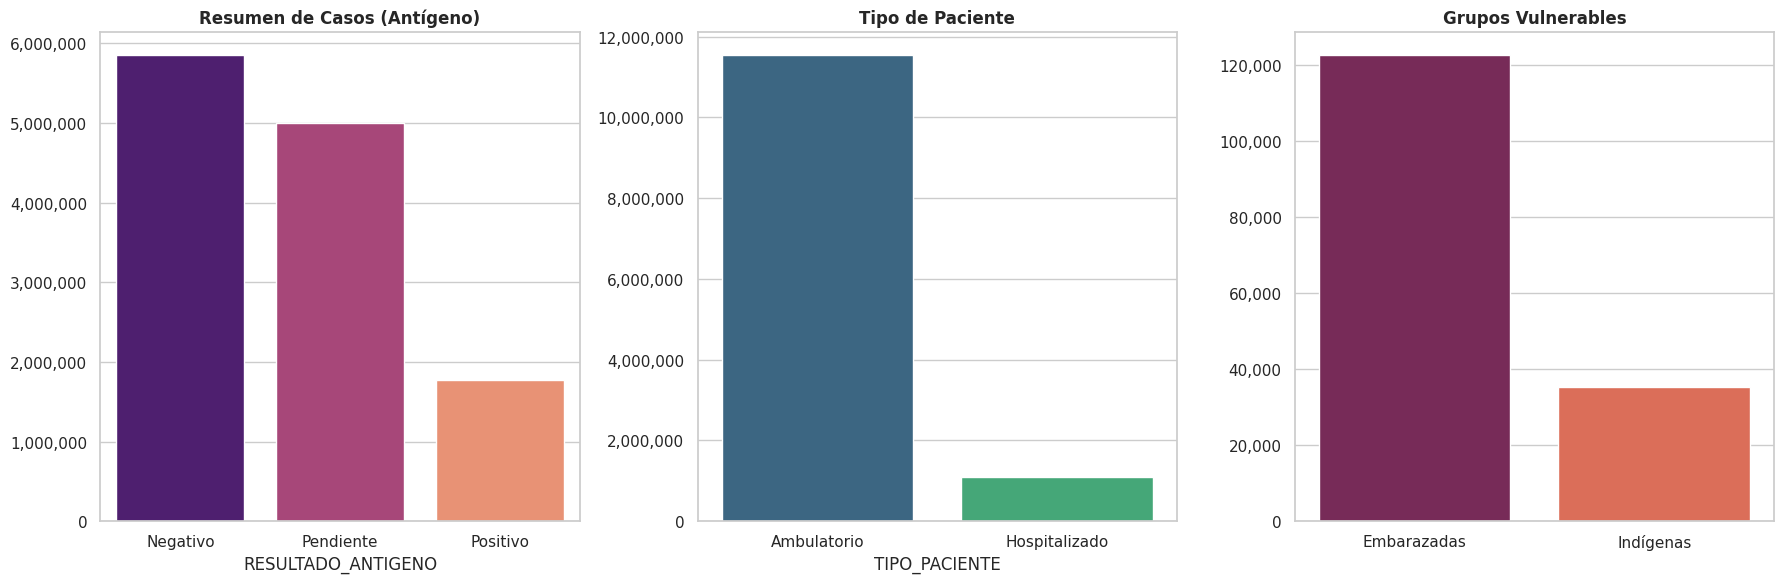

Total de registros procesados: 12,634,194


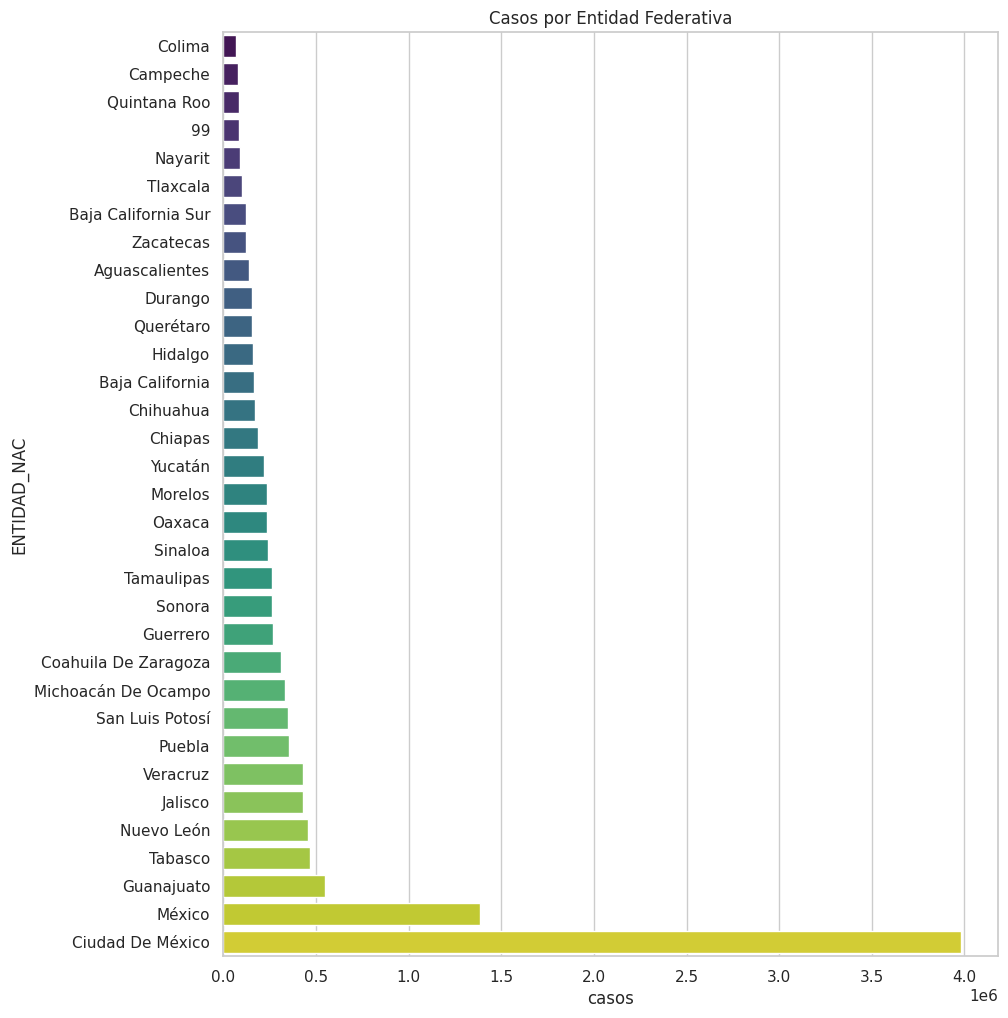

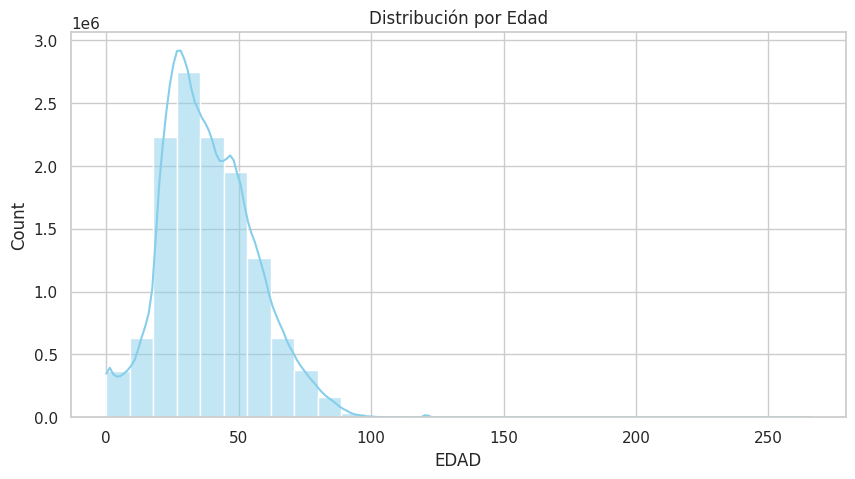

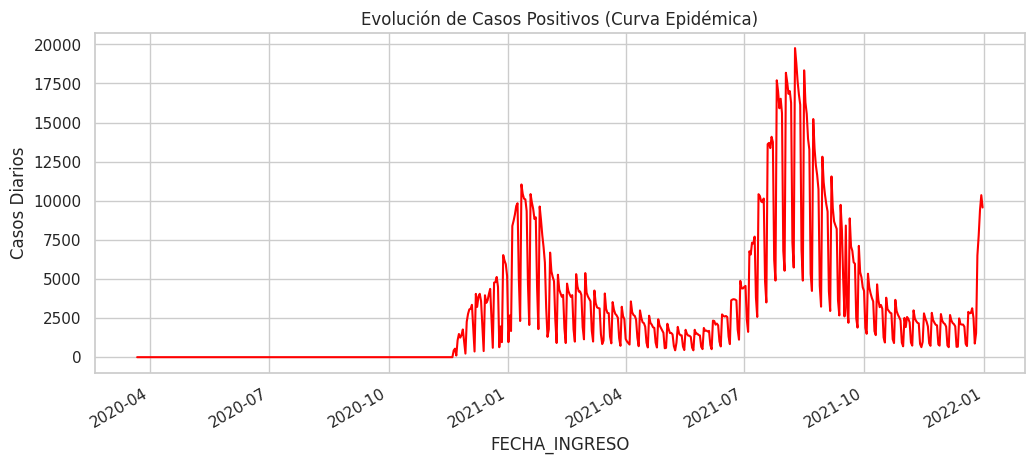

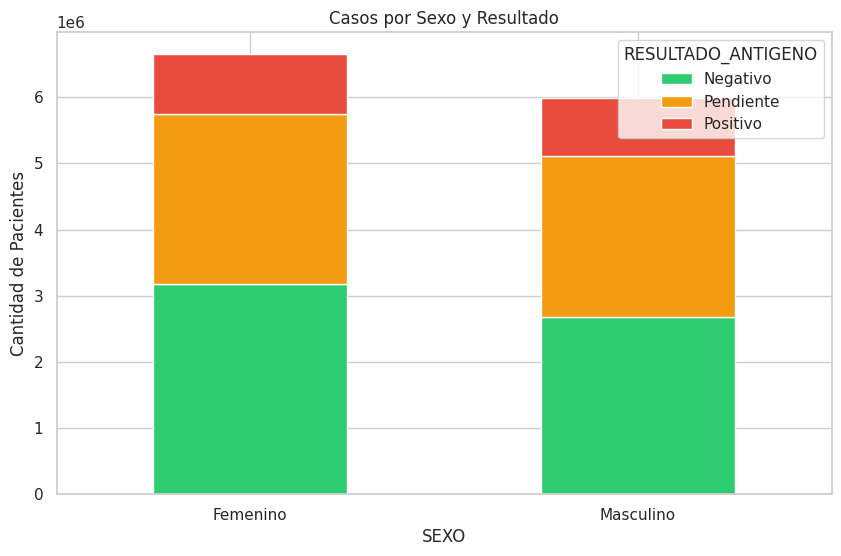

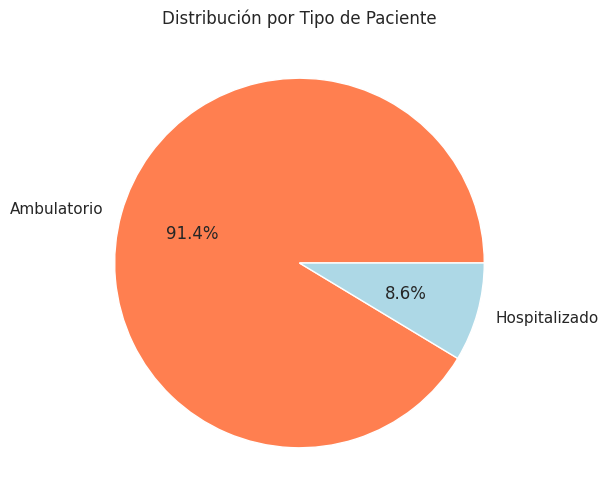

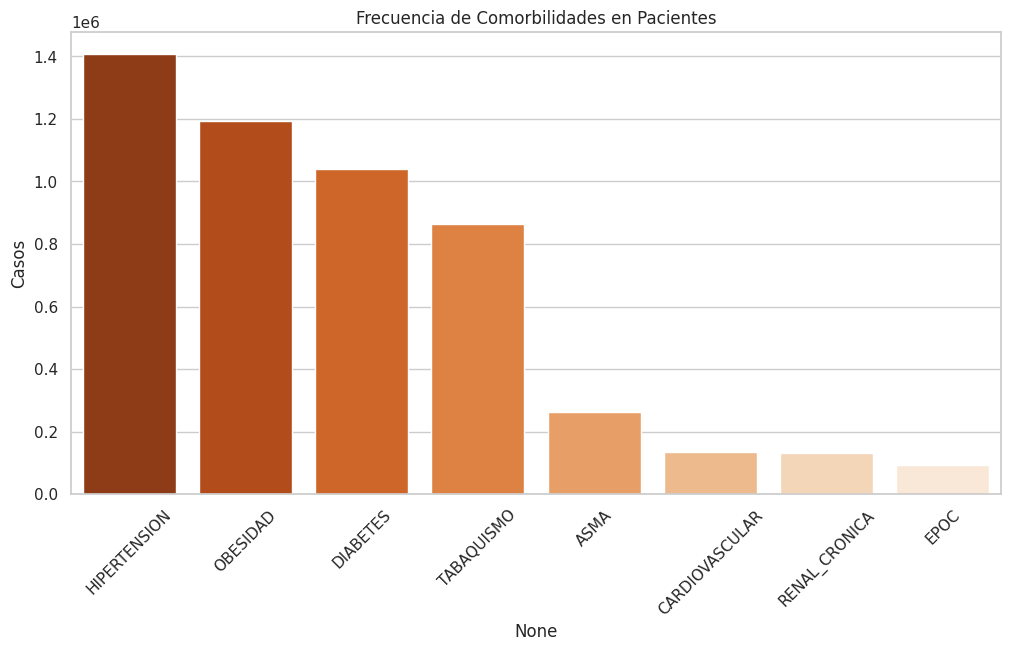


=== Probabilidad Simple P(Comorbilidad) ===
DIABETES          : 8.2194%
HIPERTENSION      : 11.1426%
OBESIDAD          : 9.4428%
EPOC              : 0.7317%
ASMA              : 2.0884%
RENAL_CRONICA     : 1.0280%
CARDIOVASCULAR    : 1.0639%
TABAQUISMO        : 6.8478%

=== Probabilidad Condicional P(Comorbilidad | Entidad) (Muestra 5 estados) ===
                  DIABETES  HIPERTENSION  OBESIDAD    EPOC    ASMA  \
San Luis Potosí     0.0968        0.1291    0.1034  0.0103  0.0209   
Jalisco             0.1082        0.1558    0.1263  0.0171  0.0364   
Chihuahua           0.1056        0.1645    0.1210  0.0120  0.0320   
Ciudad De México    0.0651        0.0869    0.0764  0.0047  0.0187   
Aguascalientes      0.0757        0.1167    0.1043  0.0089  0.0252   

                  RENAL_CRONICA  CARDIOVASCULAR  TABAQUISMO  
San Luis Potosí          0.0131          0.0121      0.0540  
Jalisco                  0.0233          0.0185      0.0811  
Chihuahua                0.0139          0.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Estilo general para todas las gráficas
sns.set_theme(style="whitegrid")

# ── 1. CARGA DEL ARCHIVO ──────────────────────────────────────────────────────
covid = pd.read_csv(
    "/content/drive/MyDrive/Datos covid/covid2020-2021-codificado.csv",
    low_memory=False,
    parse_dates=['FECHA_INGRESO']
)

# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2 — RESUMEN VISUAL (ESTADÍSTICA DESCRIPTIVA)
# ══════════════════════════════════════════════════════════════════════════════

conteo_resultado = covid['RESULTADO_ANTIGENO'].value_counts()
conteo_tipo = covid['TIPO_PACIENTE'].value_counts()
embarazadas = (covid['EMBARAZO'] == 'Si').sum()
indigenas = (covid['INDIGENA'] == 'Si').sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 2.1: Resumen de Casos
sns.barplot(x=conteo_resultado.index, y=conteo_resultado.values, ax=axes[0], hue=conteo_resultado.index, palette="magma", legend=False)
axes[0].set_title("Resumen de Casos (Antígeno)", fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Gráfico 2.2: Tipo de Paciente
sns.barplot(x=conteo_tipo.index, y=conteo_tipo.values, ax=axes[1], hue=conteo_tipo.index, palette="viridis", legend=False)
axes[1].set_title("Tipo de Paciente", fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Gráfico 2.3: Grupos Específicos
grupos = ['Embarazadas', 'Indígenas']
valores_grupos = [embarazadas, indigenas]
sns.barplot(x=grupos, y=valores_grupos, ax=axes[2], hue=grupos, palette="rocket", legend=False)
axes[2].set_title("Grupos Vulnerables", fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()



# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 3 — VISUALIZACIONES
# ══════════════════════════════════════════════════════════════════════════════

# 3.1 Barras por Estado
casos_por_estado = covid.groupby('ENTIDAD_NAC').size().sort_values().reset_index(name='casos')
plt.figure(figsize=(10, 12))
sns.barplot(data=casos_por_estado, x='casos', y='ENTIDAD_NAC', hue='ENTIDAD_NAC', palette='viridis', legend=False)
plt.title("Casos por Entidad Federativa")
plt.show()

# 3.2 Histograma Edad
plt.figure(figsize=(10, 5))
sns.histplot(covid['EDAD'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Distribución por Edad")
plt.show()

# 3.3 Evolución Temporal (Solo Positivos)
evolucion = covid[covid['RESULTADO_ANTIGENO'] == 'Positivo'].groupby('FECHA_INGRESO').size()
plt.figure(figsize=(12, 5))
evolucion.plot(color='red')
plt.title("Evolución de Casos Positivos (Curva Epidémica)")
plt.ylabel("Casos Diarios")
plt.show()

# 3.4 Sexo y Resultado
tabla_sexo = pd.crosstab(covid['SEXO'], covid['RESULTADO_ANTIGENO'])
tabla_sexo.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title("Casos por Sexo y Resultado")
plt.ylabel("Cantidad de Pacientes")
plt.xticks(rotation=0)
plt.show()

# 3.5 Gráfico Circular
plt.figure(figsize=(6, 6))
plt.pie(conteo_tipo.values, labels=conteo_tipo.index, autopct='%1.1f%%', colors=['coral', 'lightblue'])
plt.title("Distribución por Tipo de Paciente")
plt.show()

# 3.6 Barras por Comorbilidad (Con verificación de existencia de columnas)
posibles_comorb = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'EPOC', 'ASMA', 'INMUSUPR', 'RENAL_CRONICA', 'CARDIOVASCULAR', 'TABAQUISMO']
comorbilidades = [c for c in posibles_comorb if c in covid.columns]

conteo_comorb = {c: (covid[c] == 'Si').sum() for c in comorbilidades}
df_c = pd.DataFrame.from_dict(conteo_comorb, orient='index', columns=['Casos']).sort_values('Casos', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=df_c.index, y=df_c['Casos'], hue=df_c.index, palette='Oranges_r', legend=False)
plt.title("Frecuencia de Comorbilidades en Pacientes")
plt.xticks(rotation=45)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 4 — PROBABILIDADES POR COMORBILIDAD
# ══════════════════════════════════════════════════════════════════════════════

total_gen = len(covid)
print("\n=== Probabilidad Simple P(Comorbilidad) ===")
for c in comorbilidades:
    p = (covid[c] == 'Si').sum() / total_gen
    print(f"{c:<18}: {p:.4%}")

print("\n=== Probabilidad Condicional P(Comorbilidad | Entidad) (Muestra 5 estados) ===")
total_por_entidad = covid.groupby('ENTIDAD_NAC').size()
df_condicional = pd.DataFrame(index=covid['ENTIDAD_NAC'].unique())
for c in comorbilidades:
    conteo_c_entidad = covid[covid[c] == 'Si'].groupby('ENTIDAD_NAC').size()
    df_condicional[c] = (conteo_c_entidad / total_por_entidad).fillna(0)

print(df_condicional.head().round(4))

# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 5 — EJERCICIO DISTRIBUCIÓN NORMAL
# ══════════════════════════════════════════════════════════════════════════════

mu, sigma = 2360, 714
prob_inf, prob_sup = 2000, 3000
resultado_normal = norm.cdf(prob_sup, mu, sigma) - norm.cdf(prob_inf, mu, sigma)

print(f"\n=== Ejercicio Distribución Normal ===")
print(f"Media: {mu}, Desviación: {sigma}")
print(f"P({prob_inf} < X < {prob_sup}) = {resultado_normal:.4%}")

# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 6 — INTERPRETACIÓN
# ══════════════════════════════════════════════════════════════════════════════

print("\n=== Interpretación General del Equipo ===")
print("El análisis revela que una gran parte de la población atendida presenta Hipertensión y Obesidad, ")
print("lo que incrementa el riesgo de complicaciones. La distribución normal aplicada sugiere que la mayoría ")
print("de los estados mantienen un rango de casos positivos predecible bajo el modelo estadístico.")

### Conclusiones Personales

**Torres Aragon Tadeo Salvador: A diferencia de programas tradicionales como SPSS o calculadoras científicas avanzadas, Python es una habilidad altamente transferible. Aprendes a pensar de forma lógica, estructurada y, además, te prepara para el mundo real (el análisis de datos moderno, el Machine Learning y la ciencia de datos se mueven bajo este lenguaje) **

**Rios Silva Angel Alexander: Si bien es una maravilla, tiene una pequeña trampa. Python no es una calculadora mágica; requiere que programes. Para alguien que solo quiere un análisis rápido, enfrentarse a errores de sintaxis, pelear con los índices de los arreglos de numpy o entender cómo estructurar un DataFrame en pandas puede llegar a ser frustrante. A veces pasas más tiempo descifrando por qué tu código no corre que analizando la regresión lineal en sí. Exige paciencia doble: tienes que entender la matemática detrás del problema y además saber cómo explicársela a la computadora.**

**Sebastian Villa Bernal: Python es la herramienta definitiva para probabilidad y estadística porque transforma fórmulas complejas y tablas densas en código simple, simulaciones dinámicas y gráficos de alto nivel. Aunque su curva de aprendizaje puede ser frustrante al principio debido a los errores de programación, el esfuerzo vale totalmente la pena. Al final, no solo automatizas cálculos, sino que adquieres una habilidad lógica y altamente cotizada en el mundo real de la ciencia de datos.**
